In [71]:
import warnings
warnings.filterwarnings("ignore")


In [72]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="SQL_workbench16",
    database="hospital_db"
)
print("Connected successfully!")

Connected successfully!


In [74]:
patients=pd.read_sql("SELECT * FROM patients", conn)
patients.head()

,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date
0,1,53,M,Hyderabad,SecureLife,0,2025-05-14
1,2,42,M,Pune,HealthPlus,0,2025-11-18
2,3,56,F,Hyderabad,HealthPlus,0,2025-05-11
3,4,72,M,Chennai,HealthPlus,0,2025-12-18
4,5,40,F,Bangalore,CareOne,1,2025-01-23


In [75]:
visit=pd.read_sql("SELECT * FROM visit", conn)
visit.head()

,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118


In [76]:
bills=pd.read_sql("SELECT * FROM bills", conn)
bills.head()

,bill_id,visit_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,1,23577.0,0.0,Rejected,16.0,2025-06-18
1,2,2,38179.0,38179.0,Paid,18.0,2025-10-09
2,3,3,5039.0,5039.0,Paid,NaN,2025-01-20
3,4,4,22813.0,22813.0,Paid,16.0,2025-12-24
4,5,5,27107.0,27107.0,Paid,14.0,2025-09-23


In [77]:
patients.columns


Index(['patient_id', 'age', 'gender', 'city', 'insurance_provider',
       'chronic_flag', 'registration_date'],
      dtype='object')

In [78]:
visit.columns



Index(['visit_id', 'patient_id', 'visit_date', 'department', 'visit_type',
       'length_of_stay_hours', 'risk_score', 'doctor_id'],
      dtype='object')

In [79]:
bills.columns

Index(['bill_id', 'visit_id', 'billed_amount', 'approved_amount',
       'claim_status', 'payment_days', 'billing_date'],
      dtype='object')

In [80]:
print(f"Patients: {patients.shape}")
print(f"Visits: {visit.shape}")
print(f"Bills: {bills.shape}")

# To get the total number of elements (Rows * Columns)
total_elements = patients.size
print(f"Total elements in Patients table: {total_elements}")

Patients: (5000, 7)
Visits: (25000, 8)
Bills: (25000, 7)
Total elements in Patients table: 35000


In [81]:
# Start with visits, bring in patient details
df_merged = pd.merge(visit, patients, on='patient_id', how='left')

# Then bring in billing details
df_final = pd.merge(df_merged, bills, on='visit_id', how='left')


In [82]:
df_final.to_csv('capstone_project_data.csv', index=False)

In [83]:
df_final.head(10)

,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,city,insurance_provider,chronic_flag,registration_date,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,Bangalore,CareOne,1,2025-08-14,1,23577.0,0.0,Rejected,16.0,2025-06-18
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,Hyderabad,SecureLife,1,2025-10-29,2,38179.0,38179.0,Paid,18.0,2025-10-09
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,Chennai,HealthPlus,1,2025-07-04,3,5039.0,5039.0,Paid,NaN,2025-01-20
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,Delhi,MediCareX,0,2026-01-20,4,22813.0,22813.0,Paid,16.0,2025-12-24
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,Bangalore,HealthPlus,1,2025-03-29,5,27107.0,27107.0,Paid,14.0,2025-09-23
5,6,1803,2025-12-20,General,OPD,0.70,High,157,32,M,Bangalore,CareOne,0,2025-11-26,6,19454.0,19454.0,Paid,17.0,2026-01-12
6,7,4118,2025-11-12,Cardiology,OPD,6.40,Low,121,10,F,Bangalore,CareOne,1,2025-04-11,7,6269.0,4438.0,Pending,10.0,2025-11-16
7,8,1868,2025-09-18,ER,ICU,26.86,High,107,65,M,Mumbai,CareOne,0,2025-09-30,8,38179.0,38179.0,Paid,6.0,2025-06-27
8,9,295,2026-01-17,General,ER,8.31,Medium,134,51,M,Mumbai,HealthPlus,0,2025-07-18,9,21259.0,21259.0,Paid,15.0,2025-10-06
9,10,4442,2025-12-07,ER,ER,23.22,Low,107,49,F,Delhi,HealthPlus,1,2025-07-03,10,18161.0,18161.0,Paid,13.0,2025-07-16


In [84]:
# To see (rows, columns) for each table
print(f"Patients: {patients.shape}")
print(f"Visits: {visit.shape}")
print(f"Bills: {bills.shape}")

# To get the total number of elements (Rows * Columns)
total_elements = patients.size
print(f"Total elements in Patients table: {total_elements}")


Patients: (5000, 7)
Visits: (25000, 8)
Bills: (25000, 7)
Total elements in Patients table: 35000


In [85]:
print(f"final dataset: {df_final.shape}")

final dataset: (25000, 20)


In [86]:
patients.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   patient_id          5000 non-null   int64 
 1   age                 5000 non-null   int64 
 2   gender              5000 non-null   object
 3   city                5000 non-null   object
 4   insurance_provider  5000 non-null   object
 5   chronic_flag        5000 non-null   int64 
 6   registration_date   5000 non-null   object
dtypes: int64(3), object(4)
memory usage: 273.6+ KB


In [87]:
visit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   visit_id              25000 non-null  int64  
 1   patient_id            25000 non-null  int64  
 2   visit_date            25000 non-null  object 
 3   department            25000 non-null  object 
 4   visit_type            25000 non-null  object 
 5   length_of_stay_hours  25000 non-null  float64
 6   risk_score            25000 non-null  object 
 7   doctor_id             25000 non-null  int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 1.5+ MB


In [88]:
bills.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bill_id          25000 non-null  int64  
 1   visit_id         25000 non-null  int64  
 2   billed_amount    25000 non-null  float64
 3   approved_amount  23682 non-null  float64
 4   claim_status     25000 non-null  object 
 5   payment_days     24210 non-null  float64
 6   billing_date     25000 non-null  object 
dtypes: float64(3), int64(2), object(2)
memory usage: 1.3+ MB


In [89]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   visit_id              25000 non-null  int64  
 1   patient_id            25000 non-null  int64  
 2   visit_date            25000 non-null  object 
 3   department            25000 non-null  object 
 4   visit_type            25000 non-null  object 
 5   length_of_stay_hours  25000 non-null  float64
 6   risk_score            25000 non-null  object 
 7   doctor_id             25000 non-null  int64  
 8   age                   25000 non-null  int64  
 9   gender                25000 non-null  object 
 10  city                  25000 non-null  object 
 11  insurance_provider    25000 non-null  object 
 12  chronic_flag          25000 non-null  int64  
 13  registration_date     25000 non-null  object 
 14  bill_id               25000 non-null  int64  
 15  billed_amount      

Analyze missing values 

In [90]:
df_final.isnull().sum()

visit_id                   0
patient_id                 0
visit_date                 0
department                 0
visit_type                 0
length_of_stay_hours       0
risk_score                 0
doctor_id                  0
age                        0
gender                     0
city                       0
insurance_provider         0
chronic_flag               0
registration_date          0
bill_id                    0
billed_amount              0
approved_amount         1318
claim_status               0
payment_days             790
billing_date               0
dtype: int64

In [91]:
df_final[["approved_amount", "payment_days", "length_of_stay_hours"]].isnull().mean().mul(100).round(2)


approved_amount         5.27
payment_days            3.16
length_of_stay_hours    0.00
dtype: float64

Filling missing values with mean

In [92]:
df_final["approved_amount"].fillna(df_final["approved_amount"].mean(),inplace=True)

In [93]:
df_final["payment_days"].fillna(df_final["payment_days"].mean(),inplace=True)

In [94]:
df_final.isnull().sum()

visit_id                0
patient_id              0
visit_date              0
department              0
visit_type              0
length_of_stay_hours    0
risk_score              0
doctor_id               0
age                     0
gender                  0
city                    0
insurance_provider      0
chronic_flag            0
registration_date       0
bill_id                 0
billed_amount           0
approved_amount         0
claim_status            0
payment_days            0
billing_date            0
dtype: int64

In [95]:
df_final.select_dtypes(include="object").columns

Index(['visit_date', 'department', 'visit_type', 'risk_score', 'gender',
       'city', 'insurance_provider', 'registration_date', 'claim_status',
       'billing_date'],
      dtype='object')

converting object columns to category

In [96]:
cat_cols=["department", "visit_type", "risk_score", "gender",
       "city", "insurance_provider","claim_status"]
df_final[cat_cols]=df_final[cat_cols].astype("category")


In [97]:
df_final.dtypes

visit_id                   int64
patient_id                 int64
visit_date                object
department              category
visit_type              category
length_of_stay_hours     float64
risk_score              category
doctor_id                  int64
age                        int64
gender                  category
city                    category
insurance_provider      category
chronic_flag               int64
registration_date         object
bill_id                    int64
billed_amount            float64
approved_amount          float64
claim_status            category
payment_days             float64
billing_date              object
dtype: object

converting registration date,billing date ,visit date to datetime .

In [98]:
df_final['visit_date'] = pd.to_datetime(df_final['visit_date'], dayfirst=True)
df_final['registration_date'] = pd.to_datetime(df_final['registration_date'], dayfirst=True)
df_final["billing_date"]=pd.to_datetime(df_final["billing_date"],dayfirst=True)

In [99]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   visit_id              25000 non-null  int64         
 1   patient_id            25000 non-null  int64         
 2   visit_date            25000 non-null  datetime64[ns]
 3   department            25000 non-null  category      
 4   visit_type            25000 non-null  category      
 5   length_of_stay_hours  25000 non-null  float64       
 6   risk_score            25000 non-null  category      
 7   doctor_id             25000 non-null  int64         
 8   age                   25000 non-null  int64         
 9   gender                25000 non-null  category      
 10  city                  25000 non-null  category      
 11  insurance_provider    25000 non-null  category      
 12  chronic_flag          25000 non-null  int64         
 13  registration_dat

distribution analysis by department, visit_type, insurance_provider, and city.


In [100]:
#analysis for department
df_final["department"].value_counts()

department
General        4228
ER             4220
Neurology      4165
Orthopedics    4164
Cardiology     4159
ICU            4064
Name: count, dtype: int64

In [101]:
#percentage analysis for department
df_final["department"].value_counts(normalize=True) * 100


department
General        16.912
ER             16.880
Neurology      16.660
Orthopedics    16.656
Cardiology     16.636
ICU            16.256
Name: proportion, dtype: float64

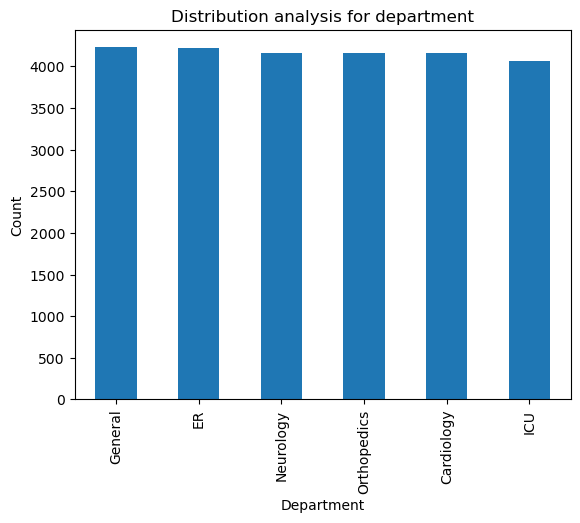

In [102]:
#distribution analysis for department using bar plot
df_final["department"].value_counts().plot(kind='bar')
plt.title("Distribution analysis for department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

In [103]:
#analysis for visit_type
df_final["visit_type"].value_counts()

visit_type
ER     8382
OPD    8381
ICU    8237
Name: count, dtype: int64

In [104]:
#percentage analysis for visit_type
df_final["visit_type"].value_counts(normalize=True) * 100

visit_type
ER     33.528
OPD    33.524
ICU    32.948
Name: proportion, dtype: float64

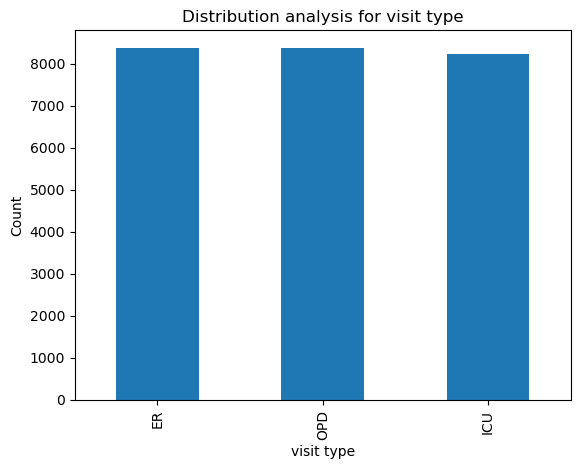

In [105]:
#distribution analysis for visit type
df_final["visit_type"].value_counts().plot(kind='bar')
plt.title("Distribution analysis for visit type")
plt.xlabel("visit type")
plt.ylabel("Count")
plt.show()

In [106]:
#analysis for insurance_provider
df_final["insurance_provider"].value_counts()

insurance_provider
MediCareX     6532
CareOne       6283
HealthPlus    6220
SecureLife    5965
Name: count, dtype: int64

In [107]:
#performance analysis for insurance_provider
df_final["insurance_provider"].value_counts(normalize=True) * 100

insurance_provider
MediCareX     26.128
CareOne       25.132
HealthPlus    24.880
SecureLife    23.860
Name: proportion, dtype: float64

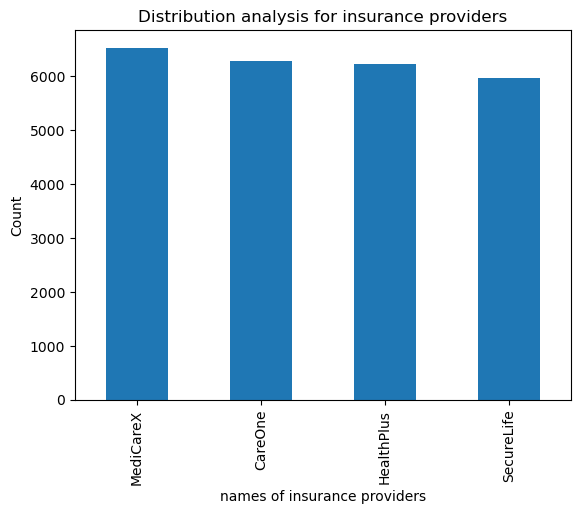

In [108]:
#distribution analysis for insurance_provider
df_final["insurance_provider"].value_counts().plot(kind='bar')
plt.title("Distribution analysis for insurance providers")
plt.xlabel("names of insurance providers")
plt.ylabel("Count")
plt.show()

In [109]:
#analysis for city
df_final["city"].value_counts()

city
Hyderabad    4370
Pune         4221
Bangalore    4205
Mumbai       4122
Delhi        4107
Chennai      3975
Name: count, dtype: int64

In [110]:
#percentage analysis for city
df_final["city"].value_counts(normalize =True ) * 100

city
Hyderabad    17.480
Pune         16.884
Bangalore    16.820
Mumbai       16.488
Delhi        16.428
Chennai      15.900
Name: proportion, dtype: float64

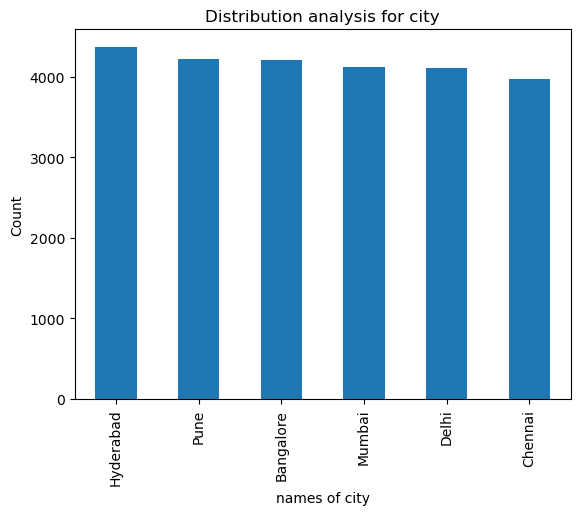

In [111]:
#distribution analysis for city
df_final["city"].value_counts().plot(kind='bar')
plt.title("Distribution analysis for city")
plt.xlabel("names of city")
plt.ylabel("Count")
plt.show()

Detect and classify outliers in billed_amount, payment_days, and length_of_stay_hours.

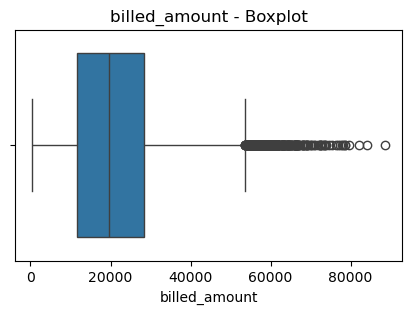

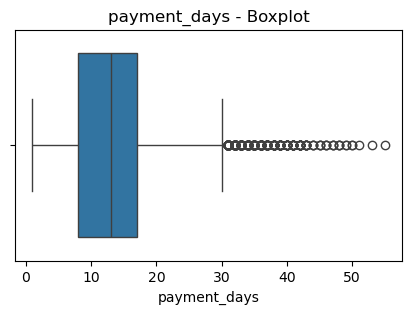

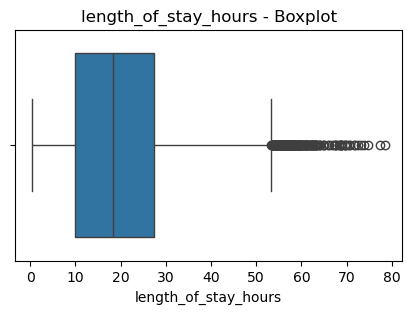

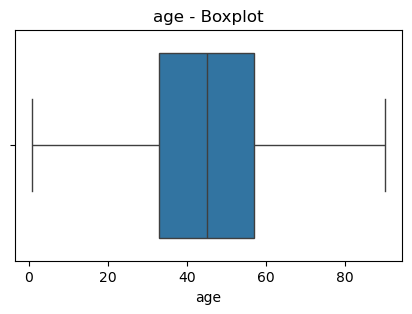

In [112]:
#box plot for outliers 
num_cols = ["billed_amount",
    "payment_days",
    "length_of_stay_hours",
    "age"]
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df_final[col])
    plt.title(f"{col} - Boxplot")
    plt.show()

In [45]:
#calculating Interquartile Range for billed_amount
Q1_bill=df_final["billed_amount"].quantile(0.25)
Q3_bill=df_final["billed_amount"].quantile(0.75)

In [46]:
IQR_bill=Q3_bill-Q1_bill

In [47]:
lower_bound_bill = Q1_bill - 1.5 * IQR_bill
upper_bound_bill =Q3_bill+ 1.5 * IQR_bill

In [48]:
outlier_bill = df_final[
    (df_final["billed_amount"] < lower_bound_bill) |
    (df_final["billed_amount"] > upper_bound_bill)
]

len(outlier_bill)


373

In [113]:
#outlier for payment_days
Q1_payment=df_final["payment_days"].quantile(0.25)
Q3_payment=df_final["payment_days"].quantile(0.75)


In [114]:
IQR_payment=Q3_payment-Q1_payment

In [115]:
lower_bound_payment=Q1_payment- 1.5 * IQR_payment
upper_bound_payment=Q3_payment+ 1.5 *IQR_payment

In [116]:
outlier_payment=df_final[
    (df_final["payment_days"]<lower_bound_payment)|
    (df_final["payment_days"]>upper_bound_payment)
    ]
len(outlier_payment)

509

In [117]:
#detecting outliers in length_of_stay_hours
Q1_stay_hours=df_final["length_of_stay_hours"].quantile(0.25)
Q3_stay_hours=df_final["length_of_stay_hours"].quantile(0.75)

In [118]:
IQR_stay_hours=Q3_stay_hours-Q1_stay_hours

In [119]:
lower_bound_stay_hours=Q1_stay_hours - 1.5 * IQR_stay_hours
upper_bound_stay_hours=Q3_stay_hours + 1.5 * IQR_stay_hours

In [120]:
outlier_stay_hours=df_final[
    (df_final["length_of_stay_hours"]<lower_bound_stay_hours)|
    (df_final["length_of_stay_hours"]>upper_bound_stay_hours)
    ]
len(outlier_stay_hours)

256

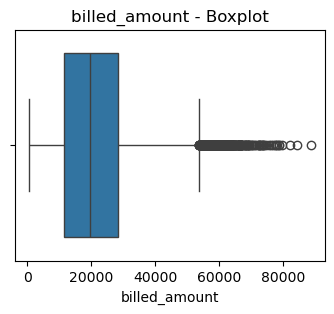

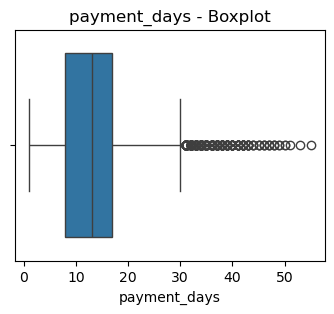

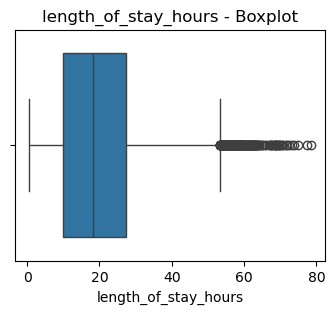

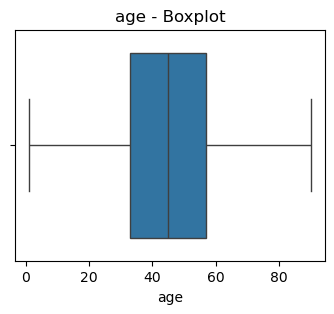

In [53]:
num_cols_after= ["billed_amount",
    "payment_days",
    "length_of_stay_hours",
    "age"]
for col in num_cols_after:
    plt.figure(figsize=(4,3))
    sns.boxplot(x=df_final[col])
    plt.title(f"{col} - Boxplot")
    plt.show()

Engineer features such as visit frequency, average length of stay per patient, provider rejection rate, days since registration, and time-based features.


In [122]:
#finding visit frequency
visit_frequency=df_final.groupby('patient_id')['visit_id'].transform("count")
print(visit_frequency)

0        2
1        4
2        4
3        7
4        5
        ..
24995    7
24996    3
24997    8
24998    6
24999    8
Name: visit_id, Length: 25000, dtype: int64


In [123]:
#creating new column for visit frequency
df_final["visit_frequency"]=(df_final.groupby('patient_id')['visit_id'].transform("count"))
df_final.head()

,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,...,insurance_provider,chronic_flag,registration_date,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date,visit_frequency
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,...,CareOne,1,2025-08-14,1,23577.0,0.0,Rejected,16.000000,2025-06-18,2
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,...,SecureLife,1,2025-10-29,2,38179.0,38179.0,Paid,18.000000,2025-10-09,4
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,...,HealthPlus,1,2025-07-04,3,5039.0,5039.0,Paid,13.048079,2025-01-20,4
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,...,MediCareX,0,2026-01-20,4,22813.0,22813.0,Paid,16.000000,2025-12-24,7
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,...,HealthPlus,1,2025-03-29,5,27107.0,27107.0,Paid,14.000000,2025-09-23,5


In [124]:
#finding average length of stay per patients
avg_length_of_stay_patients=df_final.groupby('patient_id')['length_of_stay_hours'].transform("mean")
print(avg_length_of_stay_patients)

0         3.725000
1        32.025000
2        20.542500
3        28.165714
4        22.988000
           ...    
24995    25.032857
24996    27.536667
24997    22.085000
24998    17.646667
24999    33.698750
Name: length_of_stay_hours, Length: 25000, dtype: float64


In [125]:
#creating new column for average length of stay per patients
df_final["avg_length_of_stay_patients"]=(df_final.groupby('patient_id')['length_of_stay_hours'].transform("mean"))
df_final.head()

,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,...,chronic_flag,registration_date,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date,visit_frequency,avg_length_of_stay_patients
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,...,1,2025-08-14,1,23577.0,0.0,Rejected,16.000000,2025-06-18,2,3.725000
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,...,1,2025-10-29,2,38179.0,38179.0,Paid,18.000000,2025-10-09,4,32.025000
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,...,1,2025-07-04,3,5039.0,5039.0,Paid,13.048079,2025-01-20,4,20.542500
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,...,0,2026-01-20,4,22813.0,22813.0,Paid,16.000000,2025-12-24,7,28.165714
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,...,1,2025-03-29,5,27107.0,27107.0,Paid,14.000000,2025-09-23,5,22.988000


In [127]:
#finding provider rejection rate
df_final['provider_rejection_rate'] = (
    df_final
        .groupby('insurance_provider')['claim_status']
        .transform(lambda x: (x == 'Rejected').mean() * 100)
)

df_final.head()

,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,...,registration_date,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date,visit_frequency,avg_length_of_stay_patients,provider_rejection_rate
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,...,2025-08-14,1,23577.0,0.0,Rejected,16.000000,2025-06-18,2,3.725000,14.865510
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,...,2025-10-29,2,38179.0,38179.0,Paid,18.000000,2025-10-09,4,32.025000,15.691534
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,...,2025-07-04,3,5039.0,5039.0,Paid,13.048079,2025-01-20,4,20.542500,14.967846
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,...,2026-01-20,4,22813.0,22813.0,Paid,16.000000,2025-12-24,7,28.165714,15.248010
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,...,2025-03-29,5,27107.0,27107.0,Paid,14.000000,2025-09-23,5,22.988000,14.967846


I created days_since_registration to capture patient tenure, and applied a flag plus clip method to handle negative values by marking data inconsistencies while preventing invalid negative durations from affecting the model.

In [128]:
#days since registration
df_final['days_since_registration'] = (
    df_final['visit_date'] - df_final['registration_date']
).dt.days
df_final.head()

,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,...,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date,visit_frequency,avg_length_of_stay_patients,provider_rejection_rate,days_since_registration
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,...,1,23577.0,0.0,Rejected,16.000000,2025-06-18,2,3.725000,14.865510,65
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,...,2,38179.0,38179.0,Paid,18.000000,2025-10-09,4,32.025000,15.691534,-206
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,...,3,5039.0,5039.0,Paid,13.048079,2025-01-20,4,20.542500,14.967846,9
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,...,4,22813.0,22813.0,Paid,16.000000,2025-12-24,7,28.165714,15.248010,-62
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,...,5,27107.0,27107.0,Paid,14.000000,2025-09-23,5,22.988000,14.967846,0


In [129]:
#extracting time based features
df_final['visit_month'] = df_final['visit_date'].dt.month


In [130]:
df_final['visit_year'] = df_final['visit_date'].dt.year


In [131]:
df_final['visit_dayofweek'] = df_final['visit_date'].dt.dayofweek


In [132]:
df_final.head()

,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,...,claim_status,payment_days,billing_date,visit_frequency,avg_length_of_stay_patients,provider_rejection_rate,days_since_registration,visit_month,visit_year,visit_dayofweek
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,...,Rejected,16.000000,2025-06-18,2,3.725000,14.865510,65,10,2025,5
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,...,Paid,18.000000,2025-10-09,4,32.025000,15.691534,-206,4,2025,6
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,...,Paid,13.048079,2025-01-20,4,20.542500,14.967846,9,7,2025,6
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,...,Paid,16.000000,2025-12-24,7,28.165714,15.248010,-62,11,2025,2
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,...,Paid,14.000000,2025-09-23,5,22.988000,14.967846,0,3,2025,5


In [134]:
# 1. Billing Intensity (High bill + Short stay = High Risk)
df_final['bill_per_hour'] = df_final['billed_amount'] / (df_final['length_of_stay_hours'] + 1)

# 2. Financial Discrepancy (The 'Fight' over the bill)
df_final['unapproved_gap'] = df_final['billed_amount'] - df_final['approved_amount']

# 3. Anomaly Flag (Direct signal for backdated registration)
df_final['is_backdated'] = (df_final['days_since_registration'] < 0).astype(int)

In [135]:
df_final.to_csv("capstone_phase3_features.csv", index=False)
